In [1]:
import itertools
import functools
import math
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
import numpy as np

plt.style.use("fluxoniumcr.plotting.paper")

In [2]:
def bezier_path_from_function(f, t, h=1e-6):
    xs = []
    dxs = []
    ys = []
    dys = []
    
    for i, ti in enumerate(t):
        x0, y0 = f(ti)
        if i < len(t) - 1:
            x1, y1 = f(ti+h)
            dx = (x1 - x0)/h
            dy = (y1 - y0)/h
        else:
            x1, y1 = f(ti-h)
            dx = (x0 - x1)/h
            dy = (y0 - y1)/h
        xs.append(x0)
        ys.append(y0)
        dxs.append(dx)
        dys.append(dy)
    
    vertices = [(xs[0], ys[0])]
    codes = [Path.MOVETO]
    for i in range(len(t) - 1):
        x0 = xs[i]
        x1 = xs[i+1]
        dx0 = dxs[i]
        dx1 = dxs[i+1]
        y0 = ys[i]
        y1 = ys[i+1]
        dy0 = dys[i]
        dy1 = dys[i+1]
        
        dt = t[i+1] - t[i]

        vertices.extend([
            (x0 + dx0/3 * dt, y0 + dy0/3 * dt),
            (x1 - dx1/3 * dt, y1 - dy1/3 * dt),
            (x1, y1)
        ])
        codes.extend([Path.CURVE4]*3)

    return Path(vertices, codes)

In [3]:
def pulse_cosine_envelope(t0, t1, amp, ramp_ratio):
    def f(t):
        s = (t - t0)/(t1 - t0)
        return amp * np.where(
            s < 0.0,
            0.0,
            np.where(
                s > 1.0,
                0.0,
                np.where(
                    s < ramp_ratio,
                    (1 - np.cos(np.pi*s/ramp_ratio))/2,
                    np.where(
                        s > 1 - ramp_ratio,
                        (1 - np.cos(np.pi*(1 - s)/ramp_ratio))/2,
                        1.0,
                    )
                )
            )
        )
    return f


def pulse_planck_envelope(t0, t1, amp, ramp_ratio):
    def f(t):
        s = (t - t0)/(t1 - t0)
        return amp * np.where(
            s < 0.0,
            0.0,
            np.where(
                s > 1.0,
                0.0,
                np.where(
                    s < ramp_ratio,
                    (1 - np.cos(np.pi*s/ramp_ratio))/2,
                    np.where(
                        s > 1 - ramp_ratio,
                        (1 - np.cos(np.pi*(1 - s)/ramp_ratio))/2,
                        1.0,
                    )
                )
            )
        )
    return f

In [4]:
from fluxoniumcr.simulation.signals import planck_taper_signal

t0 = -2.8
t1 = 2.8
tstart = math.floor(t0)
tend = math.ceil(t1)
amp = 1
ramp_ratio = 0.25

signal = planck_taper_signal(amplitude=1.0, total_duration=t1-t0, ramp_duration=0.25*(t1-t0), t0=t0)
envf = signal.envelope
carf = lambda t: np.sin(2*pi*t)


In [5]:
ramp_duration = ramp_ratio * (t1 - t0)

carrier_tstops = np.linspace(
    tstart,
    tend,
    round(4*(tend - tstart) + 1),
)
carrier_path = bezier_path_from_function(
    lambda t: (t, carf(t)),
    carrier_tstops,
    h=1e-9,
)
envelope_tstops = [
#     tstart,
    t0,
    *carrier_tstops[(carrier_tstops > t0) & (carrier_tstops < t0 + ramp_duration)],
    t0 + ramp_duration,
    t1 - ramp_duration,
    *carrier_tstops[(carrier_tstops > t1 - ramp_duration) & (carrier_tstops < t1)],
    t1,
#     tend,
]
envelope_path = bezier_path_from_function(
    lambda t: (t, envf(t)),
    envelope_tstops,
    h=1e-6,
)

signal_tstops = np.unique([*carrier_tstops, *envelope_tstops])[1:-1]
signal_path = bezier_path_from_function(
    lambda t: (t, envf(t)*carf(t)),
    signal_tstops,
    h=1e-6,
)

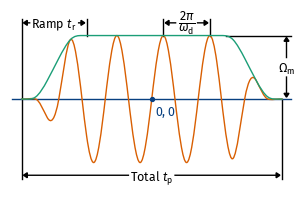

In [10]:
fig, ax = plt.subplots(
#     figsize=(85/25.4, 60/25.4),
    figsize=(75/25.4, 50/25.4),
)

fig.subplots_adjust(
    left=0.02,
    right=0.98,
    bottom=0.0,
    top=1.0,
)
ax.set_axis_off()

envelope_patch = mpl.patches.PathPatch(
    envelope_path,
    fill=False,
    linewidth=plt.rcParams['lines.linewidth'],
    edgecolor='C4',
    zorder=2,
    capstyle='projecting',
)
signal_patch = mpl.patches.PathPatch(
    signal_path,
    fill=False,
    linewidth=plt.rcParams['lines.linewidth'],
    edgecolor='C1',
    zorder=1,
    capstyle='projecting',
)
ax.add_patch(envelope_patch)
ax.add_patch(signal_patch)

total_duration_annotation_y = -1.5
ramp_duration_annotation_y = 1.2
pulse_duration_annotation_y = -1.2
amp_annotation_x = (t1 + tend)/2
drive_period_annotation_y = ramp_duration_annotation_y

ax.set_xlim(tstart - 0.05, tend + 0.05)
ax.set_ylim(total_duration_annotation_y - 0.2, ramp_duration_annotation_y + 0.2)

pulse_duration_annotation = ax.annotate(
    "Total $t_\mathrm{p}$",
    (0, pulse_duration_annotation_y),
    (0, -3.7),
    textcoords='offset points',
    ha='center',
    va='baseline',
)
ramp_duration_annotation = ax.annotate(
    "Ramp $t_\mathrm{r}$",
    (t0 + ramp_duration/2, ramp_duration_annotation_y),
    (0, -3.7),
    textcoords='offset points',
    ha='center',
    va='baseline',
)
amp_annotation = ax.annotate(
    r"$\Omega_\mathrm{m}$",
    (amp_annotation_x, amp/2),
    (0, -3.7),
    textcoords='offset points',
    ha='center',
    va='baseline',
)
drive_period_annotation = ax.annotate(
    r"$\dfrac{2\pi}{\omega_\mathrm{d}}$",
    (0.75, drive_period_annotation_y),
    (0, -3.7),
    textcoords='offset points',
    ha='center',
    va='baseline',
)

pulse_duration_annotation_gap = 1.05*pulse_duration_annotation.get_window_extent().transformed(ax.transData.inverted()).width
amp_annotation_gap = 0.6*amp_annotation.get_window_extent().transformed(ax.transData.inverted()).height
ramp_duration_annotation_gap = 1.05*ramp_duration_annotation.get_window_extent().transformed(ax.transData.inverted()).width
drive_period_annotation_gap = 1.2*drive_period_annotation.get_window_extent().transformed(ax.transData.inverted()).width


arrowprops = dict(
    arrowstyle='-|>,head_width=0.2,head_length=0.3',
    shrinkA=0,
    shrinkB=plt.rcParams['lines.linewidth']/2,
    edgecolor='black',
    facecolor='black',
    joinstyle='miter',
    capstyle='butt',
)
for a, b, y in [
        (t0, t0 + ramp_duration/2 - ramp_duration_annotation_gap/2, ramp_duration_annotation_y),
        (t0 + ramp_duration, t0 + ramp_duration/2 + ramp_duration_annotation_gap/2, ramp_duration_annotation_y),
        (t0, -pulse_duration_annotation_gap/2, pulse_duration_annotation_y),
        (t1, pulse_duration_annotation_gap/2, pulse_duration_annotation_y),
        (0.25, 0.75 - drive_period_annotation_gap/2, drive_period_annotation_y),
        (1.25, 0.75 + drive_period_annotation_gap/2, drive_period_annotation_y),
]:
    ax.annotate(
        '',
        (a, y),
        (b, y),
        arrowprops=arrowprops,
    )
    
ax.annotate(
    '',
    (amp_annotation_x, amp),
    (amp_annotation_x, amp/2 + amp_annotation_gap),
    arrowprops=arrowprops,
)
ax.annotate(
    '',
    (amp_annotation_x, 0),
    (amp_annotation_x, amp/2 - amp_annotation_gap),
    arrowprops=arrowprops,
)

arrow_head_extend = 0.06
ax.add_collection(mpl.collections.LineCollection(
    [
        [(t0, pulse_duration_annotation_y - arrow_head_extend), (t0, ramp_duration_annotation_y + arrow_head_extend)],
        [(t0+ramp_duration, 1), (t0+ramp_duration, ramp_duration_annotation_y + arrow_head_extend)],
#         [(t0, 0), (t0, pulse_duration_annotation_y - arrow_head_extend)],
        [(t1, 0), (t1, pulse_duration_annotation_y - arrow_head_extend)],
    ],
    color='black',
    zorder=0,
    capstyle='projecting',
))
ax.add_collection(mpl.collections.LineCollection(
    [
        [(t1 - ramp_duration + 0.2, amp), (tend, amp)],
    ],
    color='black',
    zorder=0,
    capstyle='projecting',
))
ax.add_collection(mpl.collections.LineCollection(
    [
        [(0.25, amp), (0.25, drive_period_annotation_y + arrow_head_extend)],
        [(1.25, amp), (1.25, drive_period_annotation_y + arrow_head_extend)],
    ],
    color='black',
    zorder=0,
    capstyle='projecting',
))
ax.add_collection(mpl.collections.LineCollection(
    [
        [(tstart, 0), (tend, 0)]
    ],
    color='C0',
    zorder=0,
    capstyle='projecting',
))

origin_annotation = ax.annotate(
    r"$0,0$",
    (0, 0),
    (2, -4),
    textcoords='offset points',
    ha='left',
    va='top',
    color='C0',
    zorder=4,
)
ax.scatter(0, 0, c='C0', zorder=4, s=8)


plt.savefig("cnot_envelope.pdf", transparent=True)

In [ ]:
0